# Bank Customer Intelligence System
## Exploratory Data Analysis (EDA)

This notebook explores the Bank Marketing Dataset before data preprocessing and model training.

In [ ]:
from pathlib import Path 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [6]:
DATA_PATH = Path("../dataset/bank-full.csv")
DATA_PATH.exists()


True

In [12]:
df =pd.read_csv(DATA_PATH ,  sep=";")
df.shape

(45211, 17)

## 3. Initial Data Inspection

In [13]:
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


In [15]:
print(df.describe())

                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.

In [16]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


## 4. Data Quality Checks

In [29]:
print(df.isnull().sum())
print(".................") 
print("The duplicate values are : " , df.duplicated().sum())
print(" the unknow things include objects are :")
(df.select_dtypes(include="object") == "unknown").sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
.................
The duplicate values are :  0
 the unknow things include objects are :


job            288
marital          0
education     1857
default          0
housing          0
loan             0
contact      13020
month            0
poutcome     36959
y                0
dtype: int64

In [30]:
unknown_percentage = (
    (df.select_dtypes(include="object") == "unknown").sum()
    / len(df)
    * 100
).round(2)

unknown_percentage[unknown_percentage > 0]

job           0.64
education     4.11
contact      28.80
poutcome     81.75
dtype: float64

## 5. Target Variable Analysis

In [34]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [35]:
df["y"].value_counts(normalize=True).mul(100).round(2)

y
no     88.3
yes    11.7
Name: proportion, dtype: float64

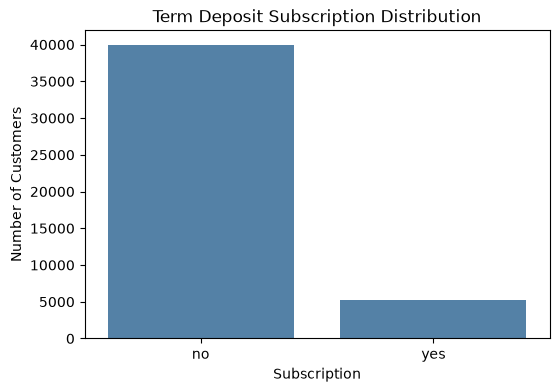

In [36]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="y", color="steelblue")

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")
plt.show()

## 6. Numerical Features Analysis

In [37]:
numerical_columns = df.select_dtypes(include="number").columns.tolist()
numerical_columns

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

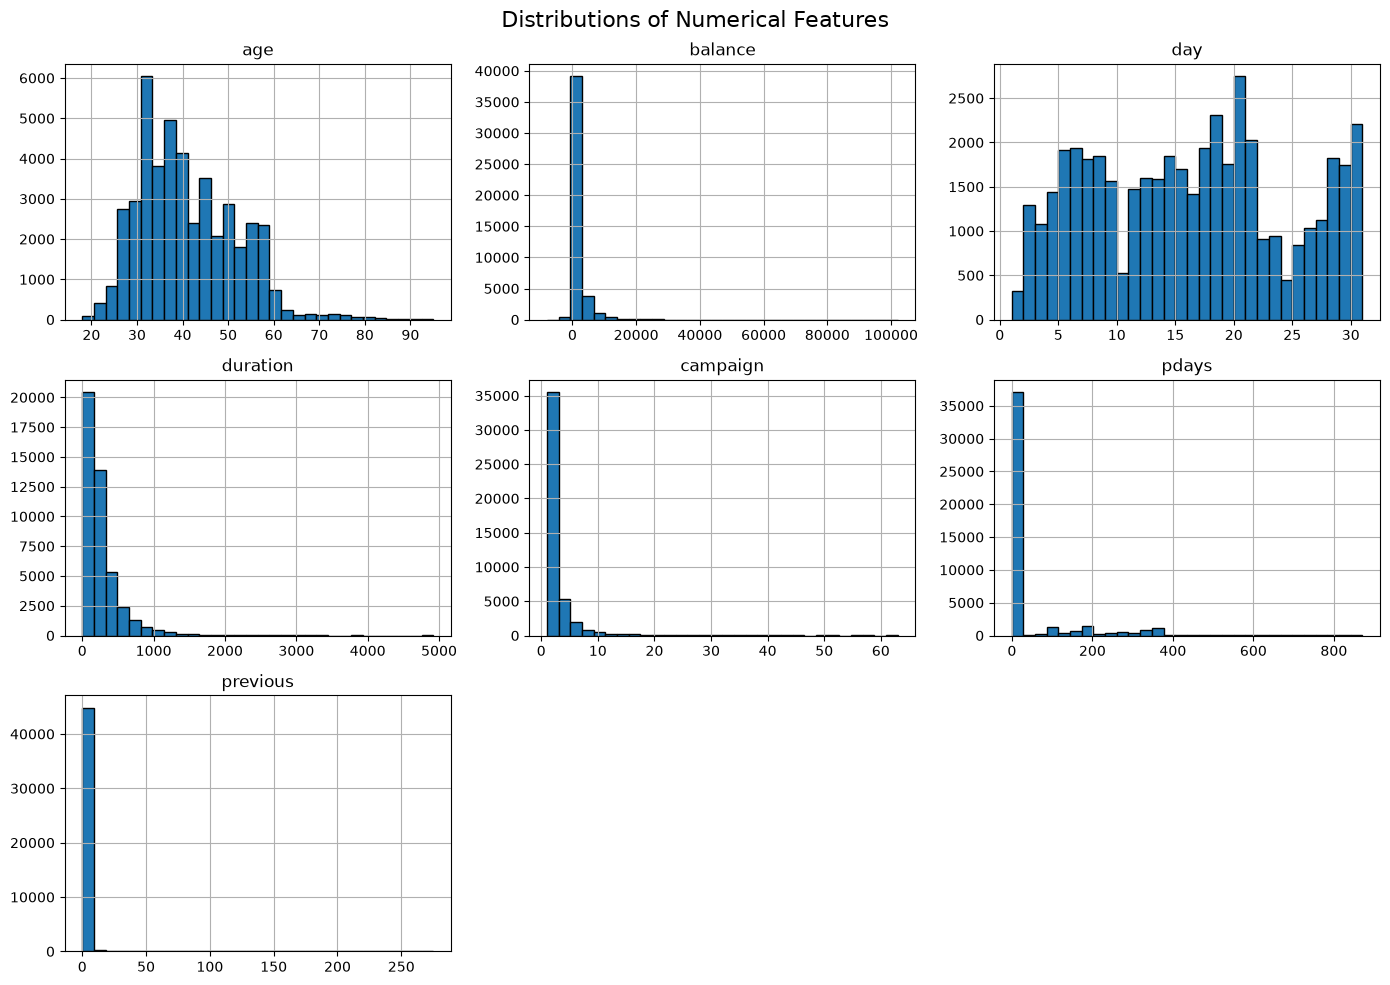

In [38]:
df[numerical_columns].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()


### Numerical Distribution Observations

- Most customers are between approximately 25 and 60 years old.
- Balance is strongly right-skewed and contains possible extreme values.
- The contact day is distributed across the days of the month.
- Duration is right-skewed and will later be removed to prevent data leakage.
- Campaign is right-skewed, with most customers contacted only a few times.
- Most customers were not contacted in a previous campaign, represented by `pdays = -1`.
- Most customers have zero previous campaign contacts.

## 7. Outlier Detection

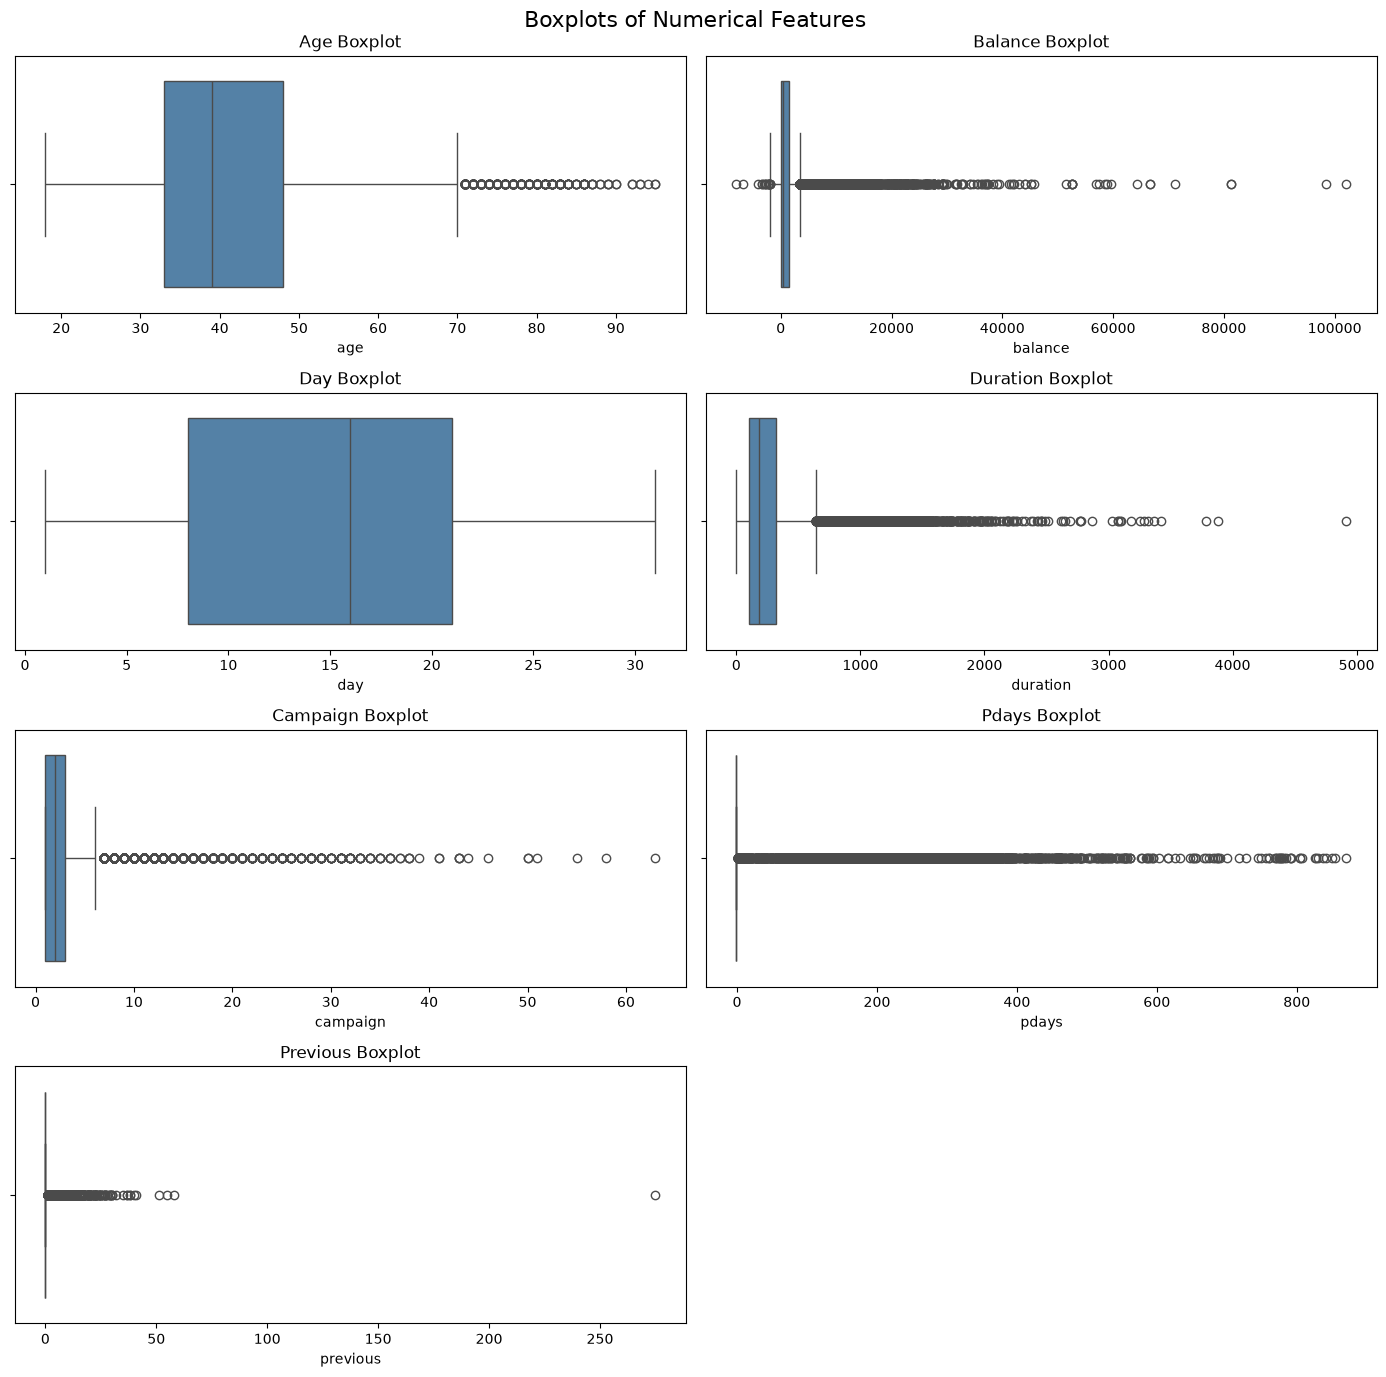

In [39]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for index, column in enumerate(numerical_columns):
    sns.boxplot(
        x=df[column],
        ax=axes[index],
        color="steelblue"
    )
    axes[index].set_title(f"{column.capitalize()} Boxplot")

fig.delaxes(axes[-1])

plt.suptitle("Boxplots of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Outlier Observations

- Age contains possible upper outliers, but the values remain within a realistic range.
- Balance contains negative values and several extreme positive values.
- Day does not show important outliers because its valid range is 1 to 31.
- Duration contains many outliers but will be removed later to prevent data leakage.
- Campaign contains customers who were contacted many times.
- Pdays contains the special value `-1`, representing customers who were not previously contacted.
- Previous is concentrated around zero and contains a few extreme values.
- Potential outliers will be investigated before deciding whether to cap, transform, or retain them.

In [41]:
outlier_columns = ["age", "balance", "campaign", "previous"]
outlier_summary = []

for column in outlier_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_percentage = round(
        outlier_count / len(df) * 100,
        2
    )

    outlier_summary.append({
        "feature": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_percentage
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,feature,lower_bound,upper_bound,outlier_count,outlier_percentage
0,age,10.5,70.5,487,1.08
1,balance,-1962.0,3462.0,4729,10.46
2,campaign,-2.0,6.0,3064,6.78
3,previous,0.0,0.0,8257,18.26


### IQR Outlier Findings

- Age has 487 possible outliers (1.08%), but older customers are valid observations.
- Balance has 4,729 possible outliers (10.46%) and requires further investigation.
- Campaign has 3,064 possible outliers (6.78%), representing customers contacted more than six times.
- Previous has 8,257 flagged values (18.26%). However, its first and third quartiles are both zero, so the IQR method classifies every non-zero value as an outlier.
- No rows will be removed based only on the IQR results.